__Основы Asyncio__

_Асинхронное программирование — это парадигма, позволяющая выполнять задачи без блокировки потока выполнения, особенно полезная для I/O-bound операций (сетевые запросы, работа с файлами, взаимодействие с БД)._

1) Неблокирующие операции: программа не ждёт завершения одной задачи, а переключается на другие
2) Эффективность: один поток может обрабатывать множество задач
3) Событийный цикл (event loop): ядро асинхронного выполнения

Основные составляющие:

Корутины (coroutines) — специальные функции, определяемые через async def

Event Loop — диспетчер, управляющий выполнением корутин

Future/Task — объекты, представляющие результат асинхронной операции

Плюсы:

1) Скорость и экономия времения, вместо x + y + x -> max(x, y, z)
2) Управляемость
3) Меньше потребление ресурсов

Минусы:

1) Теряется все сэкономленное время из-за _одного_ блокирующего вызова
2) EventLoop не резиновый (@_@) тип если будет 1000 функция, то особой пользы тож не будет


Корутина работает как генератор

Генератор - это функция, которая при выполнении вернет объект, она умеет вставать на паузу и не выполняет, что лежит внутри функции. Пример:

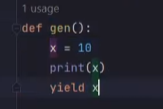

Асинхронные функции (корутины) работают так же, они возвращают объект и умеют вставать на паузу и продолжать свое выполнение.

_async_ - явный флаг того, что данная функция является асинхронной (корутиной)

Корутины нельзя просто использовать как функции, они должны использоваться внутри каких-либо механизмов

_await_ - явный флаг, что в этом месте функция встает на паузу и дает работать другим, пока ждет свои данные

Внутри корутин нужно использовать await (существуют оч редкие исключения)

В асинхронном программировании принято создавать корутину main, пример:

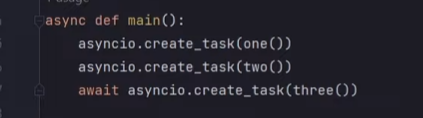

Чтобы ее выполнить необходимо использовать asyncio.run(main()) -> он блокирующий и интерпретатор ждет его выполнения

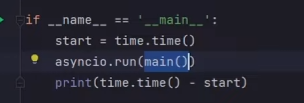

Эвейты так расставлять не стоит:

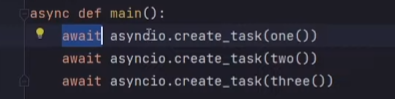

Так как у Event Loop еще нет задач каких-либо, что получить выигрыш, по сути мы синхронно вызываем асинхронные функции

Для простых случаев используется функция acyncio.gather(), которая соберет пул задач в ивент луп и выполнит их:

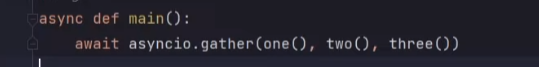

Проблема корутин без эвейтов в том, что когда ивент луп начнет ее выполнять, он будет выполнять ее всю, а мы работаем в __1 потоке__ следовательно мы будем стопаться и терять время.

По этой же причине лучше не использовть синхронизирующий код внутри корутин

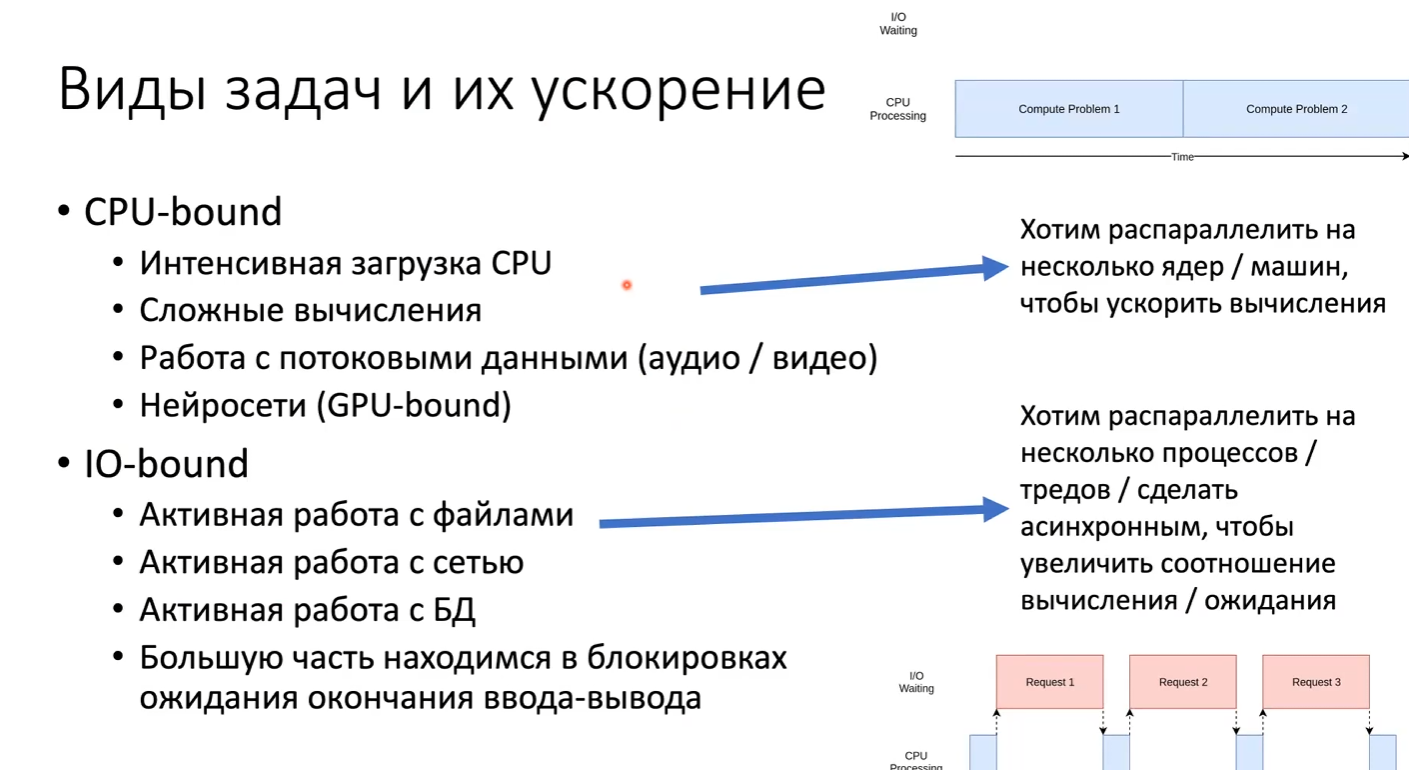

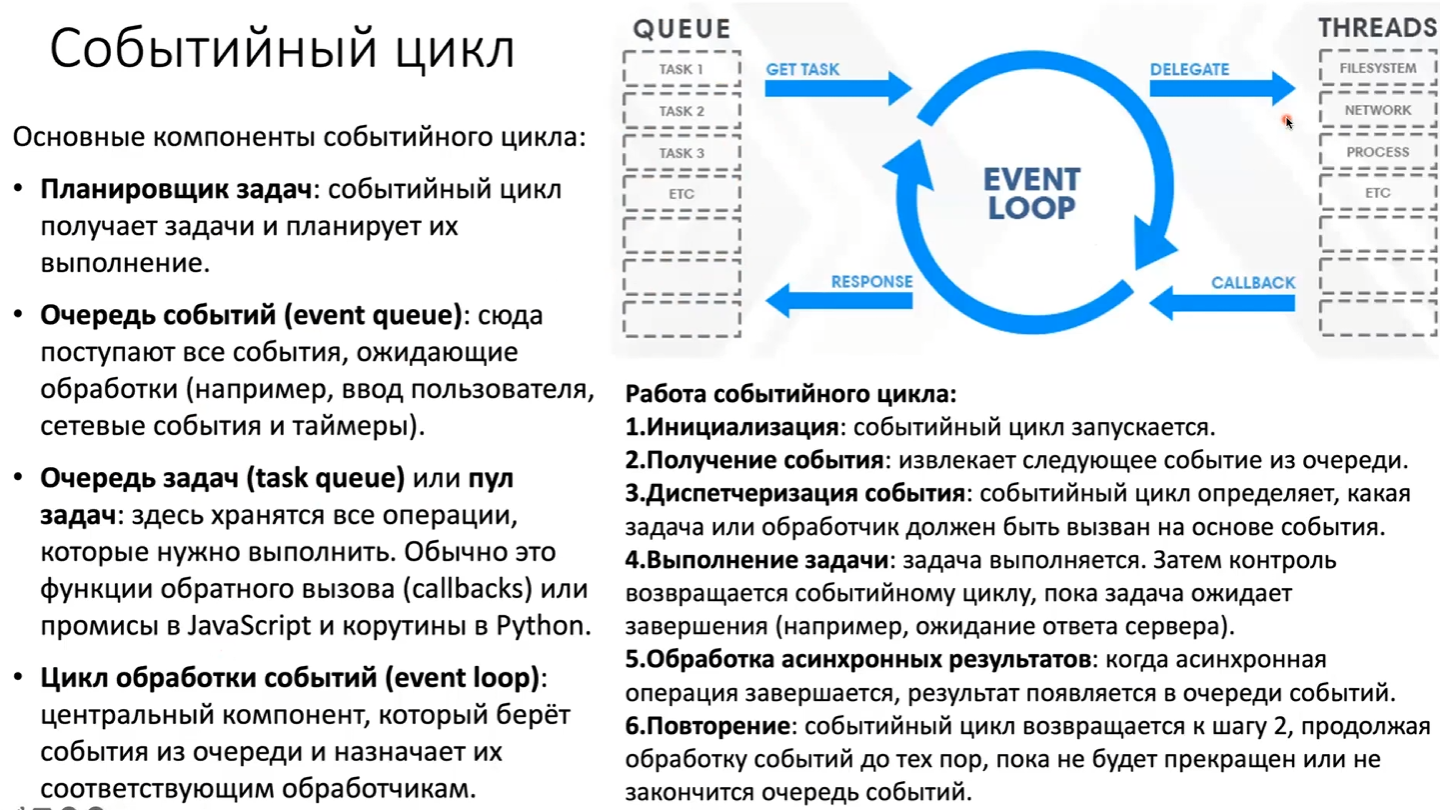

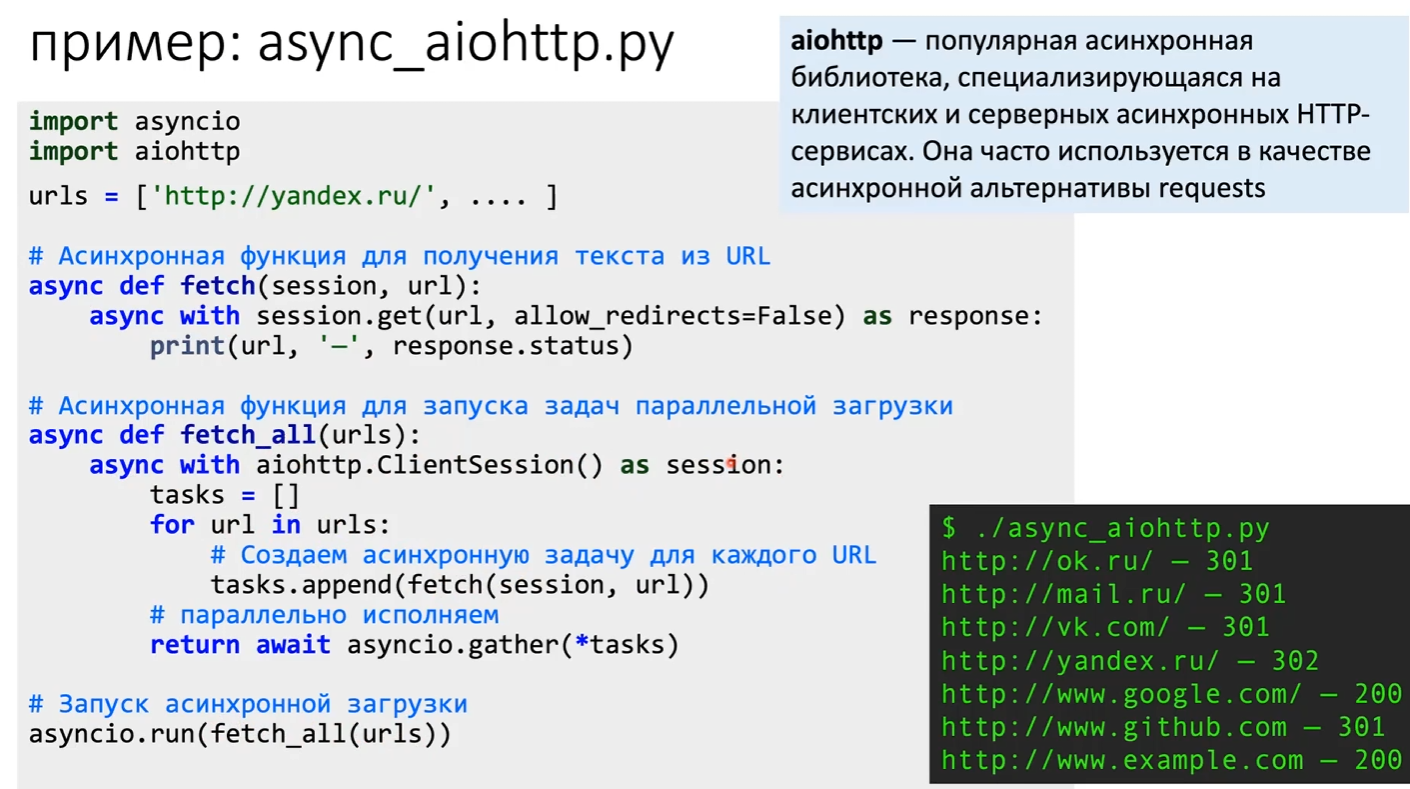